# Предсказание цен на жилье с использованием модели линейной регрессии

- Датасет: https://www.kaggle.com/competitions/two-sigma-connect-rental-listing-inquiries/overview

## 1. Imports

In [69]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as sk

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

from help_functions import *

In [70]:
!gdown 1T5lTGqpn4kyMzTTSgI0SHG-PI0aYceV9 # train.json.zip
!gdown 1bn6y3916RIAxplOd1yuabXqhYT2Hz6xZ # test.json.zip
!gdown 1YaCHM5-zflQ3H8FmtDEy0TE0NZLFsuQp # submission.csv.zip
!gdown 1WEpOWcrDHN_inVfLxJiMxLMO6nOZrmma # images_sample.zip

Downloading...
From: https://drive.google.com/uc?id=1T5lTGqpn4kyMzTTSgI0SHG-PI0aYceV9
To: /content/train.json.zip
100% 21.0M/21.0M [00:00<00:00, 47.2MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1bn6y3916RIAxplOd1yuabXqhYT2Hz6xZ
From (redirected): https://drive.google.com/uc?id=1bn6y3916RIAxplOd1yuabXqhYT2Hz6xZ&confirm=t&uuid=9646d83d-fbef-4c11-91ca-3ef9923289b0
To: /content/test.json.zip
100% 31.5M/31.5M [00:00<00:00, 72.3MB/s]
Downloading...
From: https://drive.google.com/uc?id=1YaCHM5-zflQ3H8FmtDEy0TE0NZLFsuQp
To: /content/sample_submission.csv.zip
100% 306k/306k [00:00<00:00, 84.8MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1WEpOWcrDHN_inVfLxJiMxLMO6nOZrmma
From (redirected): https://drive.google.com/uc?id=1WEpOWcrDHN_inVfLxJiMxLMO6nOZrmma&confirm=t&uuid=376076c1-e5d0-49a9-831c-2579a9e6f7c5
To: /content/images_sample.zip
100% 58.0M/58.0M [00:00<00:00, 107MB/s] 


In [71]:
zip_files = ["/content/train.json.zip",
             "/content/test.json.zip",
             "/content/sample_submission.csv.zip",
             "/content/images_sample.zip" # выборка из 100 изображений по listing_id
             ]

unzip_files(zip_files)

## 2. Exploratory Data Analysis

In [72]:
train_data = pd.read_json("/content/train.json")
train_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 49352 entries, 4 to 124009
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   bathrooms        49352 non-null  float64
 1   bedrooms         49352 non-null  int64  
 2   building_id      49352 non-null  object 
 3   created          49352 non-null  object 
 4   description      49352 non-null  object 
 5   display_address  49352 non-null  object 
 6   features         49352 non-null  object 
 7   latitude         49352 non-null  float64
 8   listing_id       49352 non-null  int64  
 9   longitude        49352 non-null  float64
 10  manager_id       49352 non-null  object 
 11  photos           49352 non-null  object 
 12  price            49352 non-null  int64  
 13  street_address   49352 non-null  object 
 14  interest_level   49352 non-null  object 
dtypes: float64(3), int64(3), object(9)
memory usage: 6.0+ MB


В описании соревнования предлагается задача мултиклассовой классификации (таргет - "interest_level"), однако в целях обучения рассмотрим задачу регрессии (таргет - "price", предсказание цены квартиры).
- Числовые признаки: bathrooms, bedrooms, latitude, longitude;
- Категориальные признаки: created, display_address, features, street_address, interest_level;
- ID: building_id, manager_id, listing_id;
- Есть изображения - photos (не везде);
- Таргет - price.

In [73]:
# убираем: display_address, street_address (позже кластеризуем по широте и долготе)
# убираем: building_id, manager_id, created
# photos, listing_id (пока что, возможно в дальнейшем используем также фото)
# description частично повторяет features (пока удалим, потом мб почистим и превратим в эмбеддинг или представление tfidf)
# почистим от выбросов по цене
# в спальнях и ваннах тоже есть какие-то значения выбросы
# interest_level - перекодируем one-hot

# парсим топ-20 популярных фичей из features - перекодируем их в 0/1

train_cleaned = run_preprocessing(train_data)
train_cleaned[:3]

Ванны и спальни почищены от выбросов.
Всё assert-ы прошли - признаки из features энкодированы корректно.


,bathrooms,bedrooms,latitude,longitude,price,interest_level,elevator,hardwoodfloors,catsallowed,dogsallowed,...,pre-war,roofdeck,outdoorspace,diningroom,highspeedinternet,balcony,swimmingpool,newconstruction,terrace,exclusive
0,1,1,40.7108,-73.9539,2400,1,0,1,1,1,...,1,0,0,1,0,0,0,0,0,0
1,1,2,40.7513,-73.9722,3800,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,2,40.7575,-73.9625,3495,1,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0


## Target analysis

<Axes: xlabel='price', ylabel='Count'>

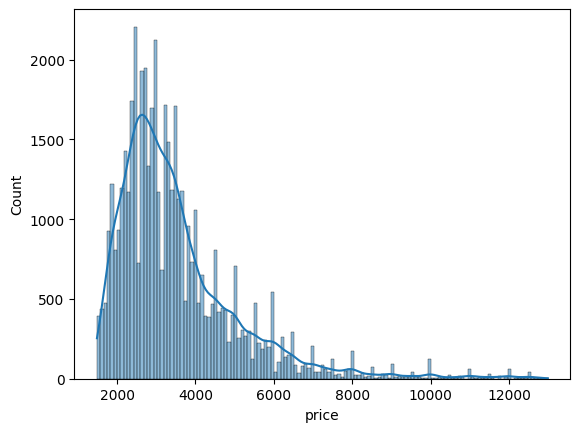

In [74]:
sns.histplot(data=train_cleaned["price"], kde=True)

- Right-skewed распределение - можно попытаться трансформировать в нормальное.

<Axes: xlabel='price'>

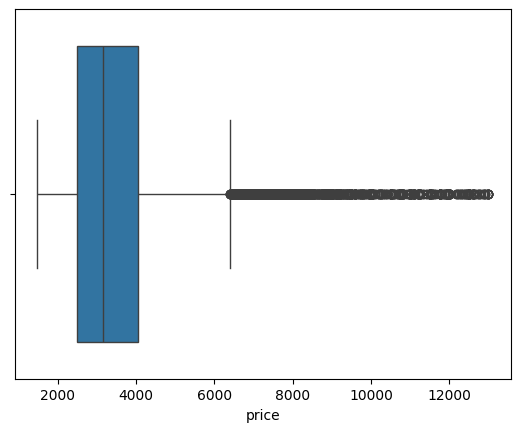

In [75]:
sns.boxplot(data=train_cleaned["price"], orient="h")

<Axes: ylabel='Count'>

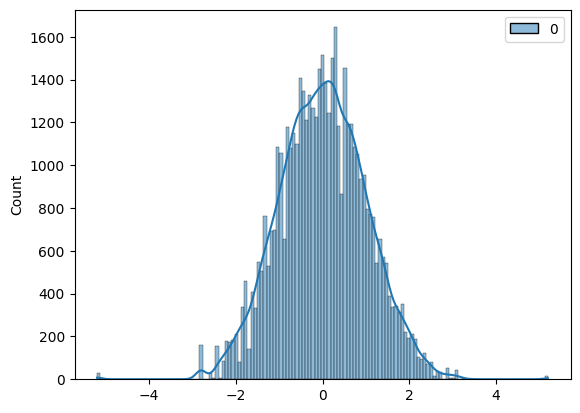

In [76]:
from sklearn.preprocessing import QuantileTransformer

qt = QuantileTransformer(n_quantiles=1000, output_distribution='normal', random_state=42)
y = np.array(train_cleaned["price"].copy()).reshape(-1,1)
transformed_y = qt.fit_transform(y)
sns.histplot(data=transformed_y, kde=True)

- распределение таргета стало "нормальнее"

<Axes: >

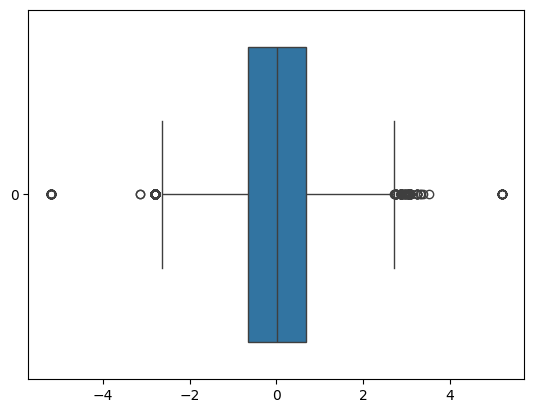

In [77]:
sns.boxplot(data=transformed_y, orient="h")

## Characteristics Analysis

<Axes: xlabel='bathrooms', ylabel='Count'>

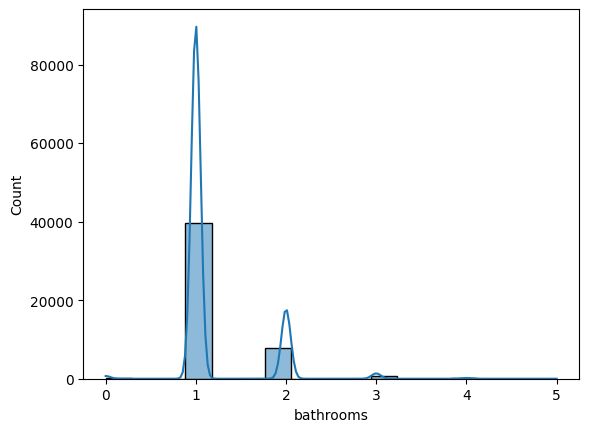

In [78]:
# bedrooms, bathrooms - выбросы убрали выше
sns.histplot(data=train_cleaned["bathrooms"], kde=True)

<Axes: xlabel='bedrooms', ylabel='Count'>

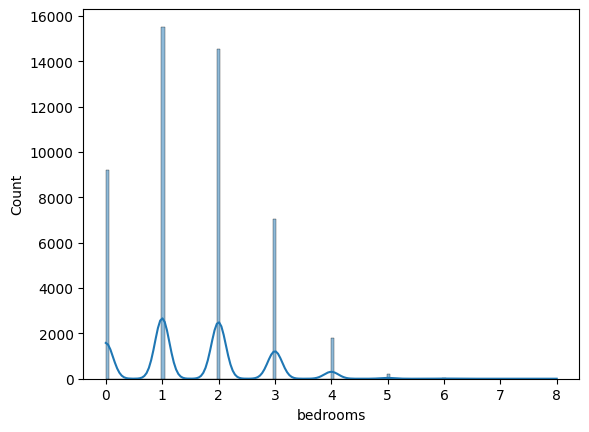

In [79]:
sns.histplot(data=train_cleaned["bedrooms"], kde=True)

## Complex analysis

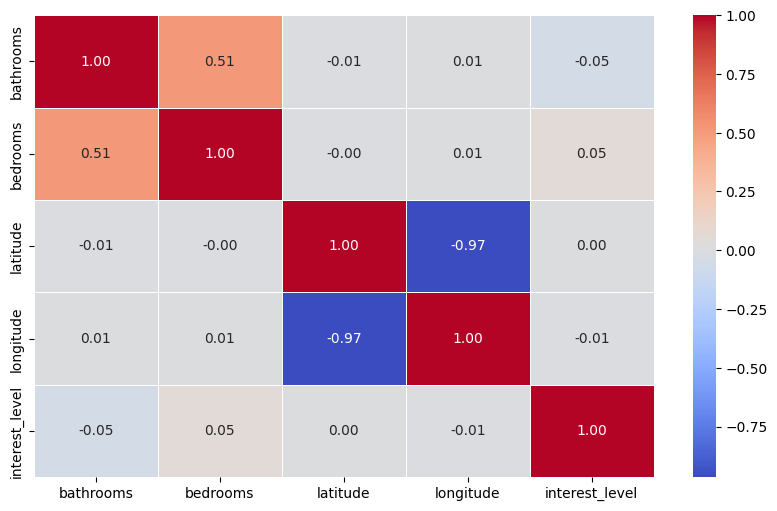

In [80]:
selected_features = ["bathrooms", "bedrooms", "latitude", "longitude", "interest_level"]
matrix = train_cleaned[selected_features].corr(numeric_only=True)
plt.figure(figsize=(10,6))
sns.heatmap(matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.show()

- сильная обратная зависимость широты и долготы (-0.97) - заменим на cluster_label позднее
- сильная прямая зависимость цены и кол-ва ванн (0.66) и спален (0.55)
- слабая обратная зависимость цены от уровня интереса (- 0.20)

# 4. Creating features

In [81]:
creative_df = train_cleaned.copy()

In [82]:
creative_df['bathrooms_bedrooms'] = creative_df['bathrooms'] * creative_df['bedrooms']
creative_df['bathrooms_more_2'] = (creative_df['bathrooms'] >= 2).astype(int)
creative_df['bedrooms_more_2'] = (creative_df['bedrooms'] >= 2).astype(int)

In [83]:
# координаты центра манхэттена
center_lat, center_lon = 40.7128, -74.0060
creative_df['dist_to_center'] = np.sqrt((creative_df['latitude'] - center_lat)**2 + (creative_df['longitude'] - center_lon)**2)
creative_df['dist_log'] = np.log(creative_df['dist_to_center']  + 1)

In [84]:
creative_df[:3]

,bathrooms,bedrooms,latitude,longitude,price,interest_level,elevator,hardwoodfloors,catsallowed,dogsallowed,...,balcony,swimmingpool,newconstruction,terrace,exclusive,bathrooms_bedrooms,bathrooms_more_2,bedrooms_more_2,dist_to_center,dist_log
0,1,1,40.7108,-73.9539,2400,1,0,1,1,1,...,0,0,0,0,0,1,0,0,0.052138,0.050825
1,1,2,40.7513,-73.9722,3800,0,1,1,0,0,...,0,0,0,0,0,2,0,1,0.051232,0.049963
2,1,2,40.7575,-73.9625,3495,1,1,1,0,0,...,0,0,0,0,0,2,0,1,0.062373,0.060505


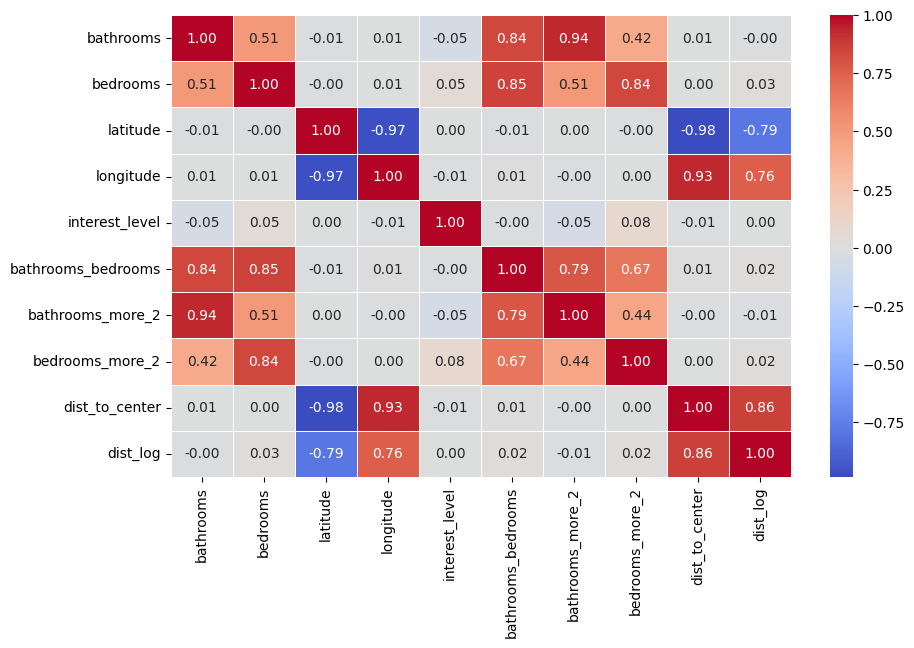

In [85]:
selected_features = ["bathrooms", "bedrooms", "latitude", "longitude", "interest_level",
                     'bathrooms_bedrooms', 'bathrooms_more_2', 'bedrooms_more_2', 'dist_to_center', 'dist_log' ]
matrix = creative_df[selected_features].corr(numeric_only=True)
plt.figure(figsize=(10,6))
sns.heatmap(matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.show()

- созданные признаки ('bathrooms_bedrooms', 'bathrooms_more_2', 'bedrooms_more_2', 'dist_log') - есть корреляция с таргетом, оставляем;
'dist_to_center' - убираем.

In [86]:
creative_df = delete_cols(creative_df, columns_to_drop=['dist_to_center'])
creative_df[:3]

,bathrooms,bedrooms,latitude,longitude,price,interest_level,elevator,hardwoodfloors,catsallowed,dogsallowed,...,highspeedinternet,balcony,swimmingpool,newconstruction,terrace,exclusive,bathrooms_bedrooms,bathrooms_more_2,bedrooms_more_2,dist_log
0,1,1,40.7108,-73.9539,2400,1,0,1,1,1,...,0,0,0,0,0,0,1,0,0,0.050825
1,1,2,40.7513,-73.9722,3800,0,1,1,0,0,...,0,0,0,0,0,0,2,0,1,0.049963
2,1,2,40.7575,-73.9625,3495,1,1,1,0,0,...,0,0,0,0,0,0,2,0,1,0.060505


In [87]:
# подправим типы данных
creative_df['bathrooms_more_2'] = creative_df['bathrooms_more_2'].astype('category')
creative_df['bedrooms_more_2'] = creative_df['bedrooms_more_2'].astype('category')
creative_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48343 entries, 0 to 48342
Data columns (total 30 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   bathrooms           48343 non-null  int64   
 1   bedrooms            48343 non-null  int64   
 2   latitude            48343 non-null  float64 
 3   longitude           48343 non-null  float64 
 4   price               48343 non-null  int64   
 5   interest_level      48343 non-null  int64   
 6   elevator            48343 non-null  int64   
 7   hardwoodfloors      48343 non-null  int64   
 8   catsallowed         48343 non-null  int64   
 9   dogsallowed         48343 non-null  int64   
 10  doorman             48343 non-null  int64   
 11  dishwasher          48343 non-null  int64   
 12  laundryinbuilding   48343 non-null  int64   
 13  nofee               48343 non-null  int64   
 14  fitnesscenter       48343 non-null  int64   
 15  laundryinunit       48343 non-null  

# 5. Add cluster_label as categorical feature too

In [88]:
# поделим на train + val
from sklearn.model_selection import train_test_split
X_train, X_val, Y_train, Y_val = train_test_split(creative_df.drop("price", axis=1),
                                                   creative_df["price"],
                                                   test_size=0.2,
                                                   random_state=42,
                                                   stratify = creative_df["interest_level"])
print(X_train.shape, Y_train.shape)
print(X_val.shape, Y_val.shape)

(38674, 29) (38674,)
(9669, 29) (9669,)


In [89]:
from sklearn.cluster import KMeans
kmeans_model = KMeans(n_clusters=30, init="k-means++", random_state=42)
X_train_ll = X_train[["latitude", "longitude"]]
X_val_ll = X_val[["latitude", "longitude"]]
kmeans_model.fit(X_train_ll)

pred_train = kmeans_model.predict(X_train_ll)
pred_val = kmeans_model.predict(X_val_ll)

# оценим качество кластеризации
from sklearn.metrics import silhouette_score
s_score_val = silhouette_score(np.asarray(X_val_ll), pred_val, random_state=42)

In [90]:
s_score_val # 0.45 - слабая/средняя структура кластеров

np.float64(0.44744748151525615)

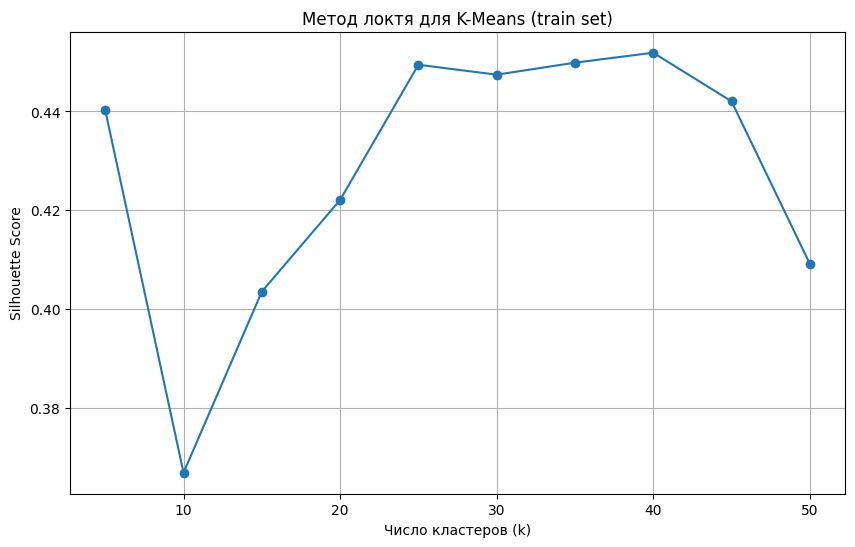

Наибольший силуэт-скор 0.4519 достигнут в случае 40 кластеров


In [91]:
silhouette_scores = []
n_clusters_range = range(5, 51, 5)

for n_clusters in n_clusters_range:
    kmeans = KMeans(n_clusters=n_clusters, init='k-means++', random_state=42)
    kmeans.fit(X_train_ll)

    val_clusters = kmeans.predict(X_val_ll)
    if len(np.unique(val_clusters)) < 2:
        score = -1.0 # если только 1 кластер в валид данных
    else:
        score = silhouette_score(X_val_ll, val_clusters, random_state=42)
    silhouette_scores.append(score)

plt.figure(figsize=(10, 6))
plt.plot(n_clusters_range, silhouette_scores, marker='o')
plt.title('Метод локтя для K-Means (train set)')
plt.xlabel('Число кластеров (k)')
plt.ylabel('Silhouette Score')
#plt.xticks(n_clusters_range[::4])
plt.grid(True)
plt.show()

best_n_clusters = n_clusters_range[np.argmax(silhouette_scores)]
max_silhouette_score = np.max(silhouette_scores)

print(f"Наибольший силуэт-скор {max_silhouette_score:.4f} достигнут в случае {best_n_clusters} кластеров")

- Из графика видно, что 25 кластеров в целом достаточно - можем проверить кач-во кластеризации методами уменьшения размерности.

In [92]:
from sklearn.manifold import TSNE

kmeans_model_25 = KMeans(n_clusters=27, init="k-means++", random_state=42)
kmeans_model_40 = KMeans(n_clusters=40, init="k-means++", random_state=42)

In [93]:
def tsne_vis(kmeans_model, X_ll):
  tsne = TSNE(n_components=2, random_state=42)
  X_tsne = tsne.fit_transform(X_ll)
  labels = kmeans_model.fit_predict(X_ll)
  plt.figure(figsize=(10,6))
  sns.scatterplot(x=X_tsne[:,0], y=X_tsne[:,1], hue=labels, palette='tab10')
  plt.title('t-SNE visualization of k-means clusters')
  plt.xlim([-50, 50])
  plt.ylim([-50, 50])
  plt.show()

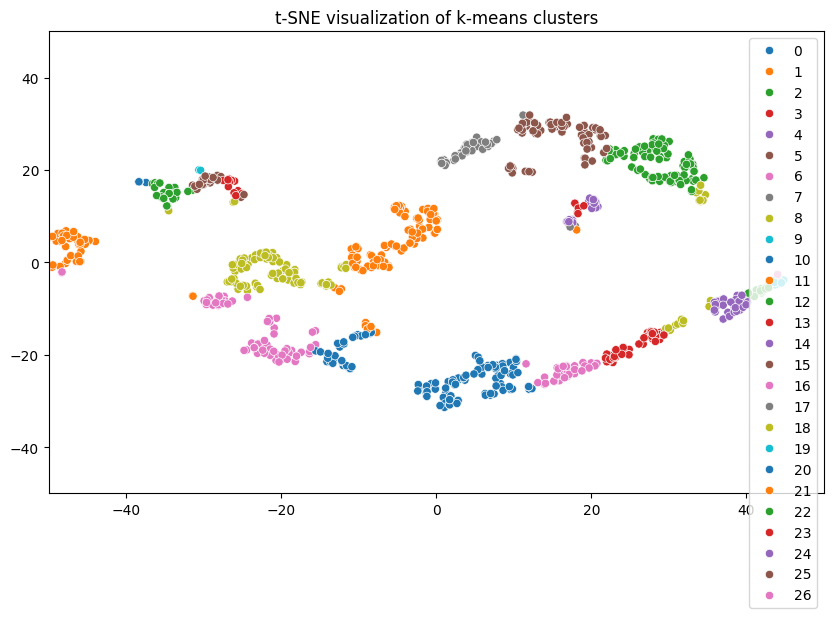

In [94]:
tsne_vis(kmeans_model_25, X_train_ll[:1000])

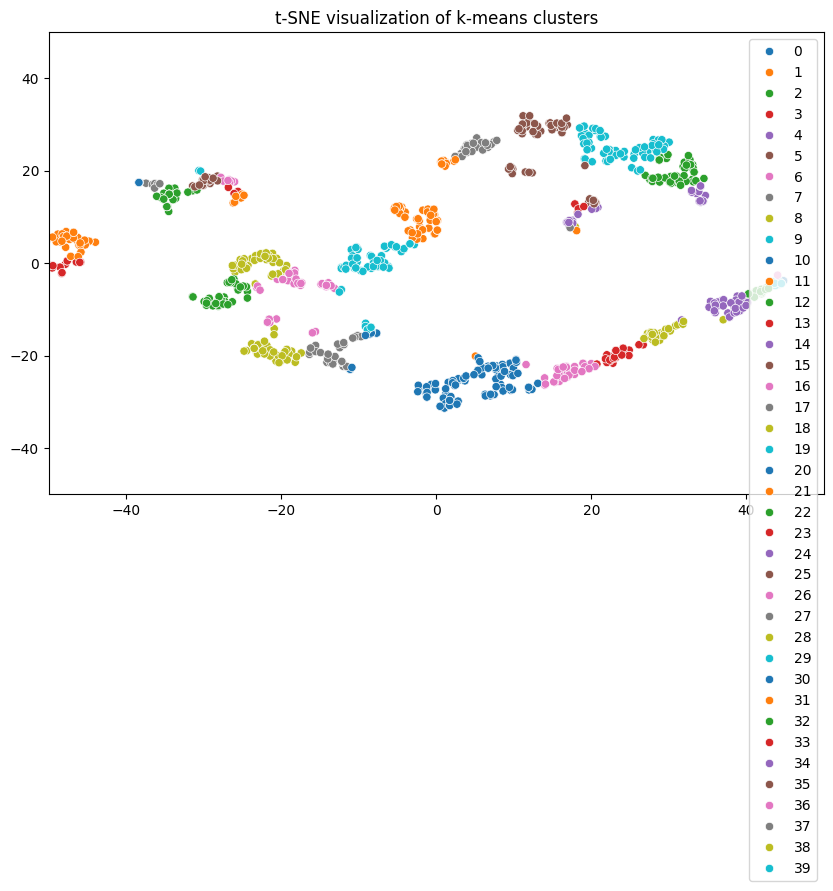

In [95]:
tsne_vis(kmeans_model_40, X_train_ll[:1000])

In [96]:
# с k=25 при проецировании на плоскость разбиение данных уже выглядит осмысленно
# но на 40 кластерах метрики итоговые лучше (без переобучения, больше параметров - больше информации)
kmeans_model = KMeans(n_clusters=40, init="k-means++", random_state=42)
X_train["cluster_label"] = kmeans_model.fit_predict(X_train_ll)
X_val["cluster_label"] = kmeans_model.predict(X_val_ll)

In [97]:
# lat, long пока оставим
X_train = delete_cols(X_train, ["features"])
X_val = delete_cols(X_val, ["features"])

In [98]:
X_train[:3]

,bathrooms,bedrooms,latitude,longitude,interest_level,elevator,hardwoodfloors,catsallowed,dogsallowed,doorman,...,balcony,swimmingpool,newconstruction,terrace,exclusive,bathrooms_bedrooms,bathrooms_more_2,bedrooms_more_2,dist_log,cluster_label
10525,1,1,40.7619,-73.9854,0,0,0,1,1,1,...,0,0,0,0,0,1,0,0,0.051877,5
39089,1,0,40.7382,-73.9965,0,1,0,1,1,1,...,0,0,0,0,0,0,0,0,0.026757,25
37274,1,2,40.6908,-73.9192,0,0,0,1,1,0,...,0,0,0,0,1,2,0,1,0.085760,13


# 6. Training

In [99]:
# трансформация таргета - qt - на практике оказалась менее оптимальна, чем обычное лог-преобразование
#qt = QuantileTransformer(n_quantiles=1000, output_distribution='normal', random_state=42)
#
#Y_train_tr = np.array(Y_train.copy()).reshape(-1,1)
#Y_train_tr = qt.fit_transform(Y_train_tr).ravel()
#
#Y_val_tr = np.array(Y_val.copy()).reshape(-1,1)
#Y_val_tr = qt.transform(Y_val_tr).ravel()
#
#sns.histplot(data=Y_train_tr, kde=True)

(38674,)

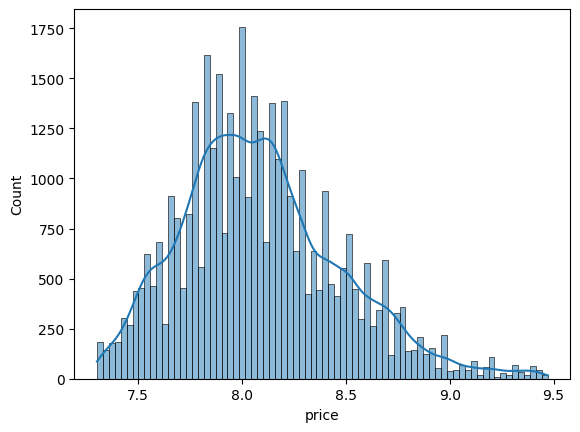

In [100]:
# трансформация таргета - log
Y_train_log = np.log1p(Y_train)
Y_val_log = np.log1p(Y_val)
sns.histplot(data=Y_train_log, kde=True)
Y_train_log.shape

In [101]:
X_train.columns

Index(['bathrooms', 'bedrooms', 'latitude', 'longitude', 'interest_level',
       'elevator', 'hardwoodfloors', 'catsallowed', 'dogsallowed', 'doorman',
       'dishwasher', 'laundryinbuilding', 'nofee', 'fitnesscenter',
       'laundryinunit', 'pre-war', 'roofdeck', 'outdoorspace', 'diningroom',
       'highspeedinternet', 'balcony', 'swimmingpool', 'newconstruction',
       'terrace', 'exclusive', 'bathrooms_bedrooms', 'bathrooms_more_2',
       'bedrooms_more_2', 'dist_log', 'cluster_label'],
      dtype='object')

In [102]:
feat_list_exp = ['bathrooms', 'bedrooms', 'latitude', 'longitude', 'interest_level',
       'elevator', 'hardwoodfloors', 'catsallowed', 'dogsallowed', 'doorman',
       'dishwasher', 'laundryinbuilding', 'nofee', 'fitnesscenter',
       'laundryinunit', 'pre-war', 'roofdeck', 'outdoorspace', 'diningroom',
       'highspeedinternet', 'balcony', 'swimmingpool', 'newconstruction',
       'terrace', 'exclusive', 'bathrooms_bedrooms', 'bathrooms_more_2',
       'bedrooms_more_2', 'dist_log', 'cluster_label']

assert feat_list_exp == list(X_train.columns), "Wrong"
assert feat_list_exp == list(X_val.columns), "Wrong"
print("Все assert-ы пройдены")

Все assert-ы пройдены


In [103]:
X_train.shape, X_val.shape

((38674, 30), (9669, 30))

In [104]:
# датафрейм для хранения результатов
dtypes = {'model': 'object', 'train': 'float64', 'valid': 'float64'}
result_MAE = pd.DataFrame(columns=['model', 'train', 'valid']).astype(dtypes)
result_MSE = pd.DataFrame(columns=['model', 'train', 'valid']).astype(dtypes)

### Отбор потенциально важных фич (кэтбуст)

In [105]:
num_cols = ["bathrooms", "bedrooms", "latitude", "longitude", "dist_log", "bathrooms_bedrooms"]
cat_cols = [col for col in X_train.columns if col not in num_cols]

In [106]:
!pip install -q catboost
from catboost import CatBoostRegressor

In [107]:
cb = CatBoostRegressor(
    iterations=1000,               # Количество деревьев
    learning_rate=0.03,            # Скорость обучения (чем ниже, тем лучше, но нужна компенсация iterations)
    depth=6,                       # Глубина дерева
    l2_leaf_reg=3,                 # L2-регуляризация для борьбы с переобучением
    loss_function='RMSE',          # Функция потерь для обучения
    eval_metric='MAE',             # Метрика для отслеживания на валидации
    cat_features=cat_cols,
    random_seed=42,
    verbose=100,                  # Печатать результат каждые 100 итераций
    early_stopping_rounds=100     # Остановиться, если метрика на валидации не улучшается
)

cb.fit(
    X_train, Y_train_log,
    eval_set=(X_val, Y_val_log),
    use_best_model=True,
    verbose=100
)

0:	learn: 0.2972811	test: 0.2946859	best: 0.2946859 (0)	total: 27.4ms	remaining: 27.4s
100:	learn: 0.1356921	test: 0.1334238	best: 0.1334238 (100)	total: 4.57s	remaining: 40.6s
200:	learn: 0.1226966	test: 0.1208245	best: 0.1208245 (200)	total: 9.18s	remaining: 36.5s
300:	learn: 0.1173918	test: 0.1159023	best: 0.1159023 (300)	total: 20s	remaining: 46.5s
400:	learn: 0.1135547	test: 0.1126368	best: 0.1126368 (400)	total: 28.2s	remaining: 42.1s
500:	learn: 0.1107743	test: 0.1102547	best: 0.1102547 (500)	total: 32.5s	remaining: 32.4s
600:	learn: 0.1086723	test: 0.1086081	best: 0.1086081 (600)	total: 37.6s	remaining: 25s
700:	learn: 0.1070081	test: 0.1074284	best: 0.1074284 (700)	total: 43s	remaining: 18.3s
800:	learn: 0.1054600	test: 0.1062951	best: 0.1062951 (800)	total: 48.7s	remaining: 12.1s
900:	learn: 0.1040977	test: 0.1052934	best: 0.1052934 (900)	total: 52.1s	remaining: 5.72s
999:	learn: 0.1030012	test: 0.1045050	best: 0.1045050 (999)	total: 54s	remaining: 0us

bestTest = 0.104504998

CatBoostRegressor(cat_features=['interest_level', 'elevator', 'hardwoodfloors', 'catsallowed', 'dogsallowed', 'doorman', 'dishwasher', 'laundryinbuilding', 'nofee', 'fitnesscenter', 'laundryinunit', 'pre-war', 'roofdeck', 'outdoorspace', 'diningroom', 'highspeedinternet', 'balcony', 'swimmingpool', 'newconstruction', 'terrace', 'exclusive', 'bathrooms_more_2', 'bedrooms_more_2', 'cluster_label'], depth=6, early_stopping_rounds=100, eval_metric='MAE', iterations=1000, l2_leaf_reg=3, learning_rate=0.03, loss_function='RMSE', random_seed=42, verbose=100)

In [108]:
train_pred = cb.predict(X_train)
val_pred = cb.predict(X_val)

train_pred_orig  = np.expm1(train_pred)
val_pred_orig = np.expm1(val_pred)

train_mae = mean_absolute_error(Y_train, train_pred_orig)
valid_mae = mean_absolute_error(Y_val, val_pred_orig)

train_rmse = np.sqrt(mean_squared_error(Y_train, train_pred_orig))
valid_rmse = np.sqrt(mean_squared_error(Y_val, val_pred_orig))

In [109]:
new_mae = pd.DataFrame({
    'model': ['catboost_regression_baseline'],
    'train': [train_mae],
    'valid': [valid_mae]
})

new_rmse = pd.DataFrame({
    'model': ['catboost_regression_baseline'],
    'train': [train_rmse],
    'valid': [valid_rmse]
})

result_MAE = pd.concat([result_MAE, new_mae], ignore_index=True)
result_MSE = pd.concat([result_MSE, new_rmse], ignore_index=True)

In [110]:
feature_importance = cb.get_feature_importance()
fi_df = pd.DataFrame({'feature': X_train.columns, 'importance': feature_importance})
fi_df.sort_values('importance', ascending=False).head(20)

,feature,importance
25,bathrooms_bedrooms,21.072394
3,longitude,13.475125
28,dist_log,11.562713
1,bedrooms,11.547212
2,latitude,8.683985
9,doorman,6.460722
4,interest_level,5.825502
0,bathrooms,4.726778
27,bedrooms_more_2,3.077742
26,bathrooms_more_2,3.057018


In [111]:
result_MAE

,model,train,valid
0,catboost_regression_baseline,389.916658,393.987811


In [112]:
result_MSE

,model,train,valid
0,catboost_regression_baseline,642.484176,638.224122


- В целом по метрикам базовый catboost уже дает хороший результат (ошибка порядка 390$ при разбросе цены от 1000 до 120000), но попробуем использовать результат - коэффициенты важности фич - чтобы приблизиться к похожему качеству для других моделей.

### Linear Regression

In [113]:
X_train.columns

Index(['bathrooms', 'bedrooms', 'latitude', 'longitude', 'interest_level',
       'elevator', 'hardwoodfloors', 'catsallowed', 'dogsallowed', 'doorman',
       'dishwasher', 'laundryinbuilding', 'nofee', 'fitnesscenter',
       'laundryinunit', 'pre-war', 'roofdeck', 'outdoorspace', 'diningroom',
       'highspeedinternet', 'balcony', 'swimmingpool', 'newconstruction',
       'terrace', 'exclusive', 'bathrooms_bedrooms', 'bathrooms_more_2',
       'bedrooms_more_2', 'dist_log', 'cluster_label'],
      dtype='object')

- Наиболее оптимальным для линейной регрессии оказался следующий пайплайн:
- полиномиальные фичи от логарифма расстояния, кол-ва ванн и спален;
- обработка "interest_level", "cluster_label" как категориальных фич через OHE;
- отобранные на кэтбусте по важности признаки из топ20: "doorman", "fitnesscenter", "elevator", "laundryinunit" (они уже энкодированы как 0/1 после препроцессинга).

In [114]:
center = (40.7128, -74.0060)
X_train['dist'] = np.log(((X_train['latitude']-center[0])**2 + (X_train['longitude']-center[1])**2)**0.5 + 1)
X_val['dist'] = np.log(((X_val['latitude']-center[0])**2 + (X_val['longitude']-center[1])**2)**0.5 + 1)

In [115]:
X_train_new = X_train[["bathrooms", "bedrooms", "latitude", "longitude", "dist","doorman", "interest_level","cluster_label", "fitnesscenter", "elevator", "laundryinunit"]].copy()
X_val_new = X_val[["bathrooms", "bedrooms", "latitude", "longitude", "dist", "doorman", "interest_level","cluster_label", "fitnesscenter", "elevator", "laundryinunit"]].copy()

In [116]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler


preprocessor = ColumnTransformer([
    ('poly', PolynomialFeatures(2), ["bathrooms", "bedrooms", 'dist']),
    ('cat', OneHotEncoder(drop='first', sparse_output=False), ["interest_level", "cluster_label"]),
    ('other', 'passthrough', ["doorman", "latitude", "longitude", "fitnesscenter", "elevator", "laundryinunit"])
])

In [117]:
from sklearn.pipeline import Pipeline
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('scaler', StandardScaler()),
    ('regressor', LinearRegression())
])

In [118]:
# логарифмируем таргет
Y_train_log = np.log1p(Y_train)
Y_val_log = np.log1p(Y_val)

In [119]:
pipeline.fit(X_train_new, Y_train_log)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('poly', PolynomialFeatures(),
                                                  ['bathrooms', 'bedrooms',
                                                   'dist']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                sparse_output=False),
                                                  ['interest_level',
                                                   'cluster_label']),
                                                 ('other', 'passthrough',
                                                  ['doorman', 'latitude',
                                                   'longitude', 'fitnesscenter',
                                                   'elevator',
                                                   'laundryinunit'])])),
                ('scaler', StandardScaler()),
                ('regressor', LinearRegression())])

In [120]:
train_pred = pipeline.predict(X_train_new)
val_pred = pipeline.predict(X_val_new)

# возвращаем таргет к первоначальному масштабу
train_pred_orig  = np.expm1(train_pred)
val_pred_orig = np.expm1(val_pred)

train_mae = mean_absolute_error(Y_train, train_pred_orig)
valid_mae = mean_absolute_error(Y_val, val_pred_orig)

train_rmse = np.sqrt(mean_squared_error(Y_train, train_pred_orig))
valid_rmse = np.sqrt(mean_squared_error(Y_val, val_pred_orig))

In [121]:
new_mae = pd.DataFrame({
    'model': ['linear_regression'],
    'train': [train_mae],
    'valid': [valid_mae]
})

new_rmse = pd.DataFrame({
    'model': ['linear_regression'],
    'train': [train_rmse],
    'valid': [valid_rmse]
})

result_MAE = pd.concat([result_MAE, new_mae], ignore_index=True)
result_MSE = pd.concat([result_MSE, new_rmse], ignore_index=True)

In [122]:
result_MAE

,model,train,valid
0,catboost_regression_baseline,389.916658,393.987811
1,linear_regression,539.090353,528.487086


In [123]:
result_MSE

,model,train,valid
0,catboost_regression_baseline,642.484176,638.224122
1,linear_regression,864.616528,829.321481


### CatboostRegressor

- попробуем кэтбуст c отобранными фичами, как категориальные фичи передаем те же "interest_level", "cluster_label"; остальные считаются числовыми

In [124]:
cat_cols = ["interest_level", "cluster_label"]

In [125]:
cb = CatBoostRegressor(
    iterations=1000,               # Количество деревьев
    learning_rate=0.03,            # Скорость обучения (чем ниже, тем лучше, но нужна компенсация iterations)
    depth=6,                       # Глубина дерева
    l2_leaf_reg=3,                 # L2-регуляризация для борьбы с переобучением
    loss_function='RMSE',          # Функция потерь для обучения
    eval_metric='MAE',             # Метрика для отслеживания на валидации
    cat_features=cat_cols,
    random_seed=42,
    verbose=100,                  # Печатать результат каждые 100 итераций
    early_stopping_rounds=100     # Остановиться, если метрика на валидации не улучшается
)

cb.fit(
    X_train_new, Y_train_log,
    eval_set=(X_val_new, Y_val_log),
    use_best_model=True,
    verbose=100
)

0:	learn: 0.2973415	test: 0.2947909	best: 0.2947909 (0)	total: 45.9ms	remaining: 45.9s
100:	learn: 0.1369981	test: 0.1346667	best: 0.1346667 (100)	total: 4.38s	remaining: 39s
200:	learn: 0.1249264	test: 0.1229184	best: 0.1229184 (200)	total: 11s	remaining: 43.9s
300:	learn: 0.1202154	test: 0.1186652	best: 0.1186652 (300)	total: 21.7s	remaining: 50.3s
400:	learn: 0.1173954	test: 0.1161543	best: 0.1161543 (400)	total: 26.6s	remaining: 39.7s
500:	learn: 0.1150030	test: 0.1141898	best: 0.1141898 (500)	total: 31s	remaining: 30.8s
600:	learn: 0.1130456	test: 0.1125470	best: 0.1125470 (600)	total: 36s	remaining: 23.9s
700:	learn: 0.1113668	test: 0.1111894	best: 0.1111894 (700)	total: 43.5s	remaining: 18.6s
800:	learn: 0.1100591	test: 0.1102286	best: 0.1102286 (800)	total: 48.9s	remaining: 12.2s
900:	learn: 0.1088400	test: 0.1092553	best: 0.1092553 (900)	total: 50.9s	remaining: 5.59s
999:	learn: 0.1076753	test: 0.1083143	best: 0.1083143 (999)	total: 52.7s	remaining: 0us

bestTest = 0.108314302

CatBoostRegressor(cat_features=['interest_level', 'cluster_label'], depth=6, early_stopping_rounds=100, eval_metric='MAE', iterations=1000, l2_leaf_reg=3, learning_rate=0.03, loss_function='RMSE', random_seed=42, verbose=100)

In [126]:
train_pred = cb.predict(X_train_new)
val_pred = cb.predict(X_val_new)


train_pred_orig  = np.expm1(train_pred)
val_pred_orig = np.expm1(val_pred)

train_mae = mean_absolute_error(Y_train, train_pred_orig)
valid_mae = mean_absolute_error(Y_val, val_pred_orig)

train_rmse = np.sqrt(mean_squared_error(Y_train, train_pred_orig))
valid_rmse = np.sqrt(mean_squared_error(Y_val, val_pred_orig))

In [127]:
new_mae = pd.DataFrame({
    'model': ['catboost_regression_fe'],
    'train': [train_mae],
    'valid': [valid_mae]
})

new_rmse = pd.DataFrame({
    'model': ['catboost_regression_fe'],
    'train': [train_rmse],
    'valid': [valid_rmse]
})

result_MAE = pd.concat([result_MAE, new_mae], ignore_index=True)
result_MSE = pd.concat([result_MSE, new_rmse], ignore_index=True)

In [128]:
result_MAE

,model,train,valid
0,catboost_regression_baseline,389.916658,393.987811
1,linear_regression,539.090353,528.487086
2,catboost_regression_fe,406.340491,406.758419


In [129]:
result_MSE

,model,train,valid
0,catboost_regression_baseline,642.484176,638.224122
1,linear_regression,864.616528,829.321481
2,catboost_regression_fe,664.393986,655.204705


###

### Decision Tree

In [130]:
tree_model = DecisionTreeRegressor(random_state=42)
tree_model.fit(X_train_new, Y_train_log)

DecisionTreeRegressor(random_state=42)

In [131]:
train_pred = tree_model.predict(X_train_new)
val_pred = tree_model.predict(X_val_new)

train_pred_orig = np.expm1(train_pred)
val_pred_orig = np.expm1(val_pred)

train_mae = mean_absolute_error(Y_train, train_pred_orig)
valid_mae = mean_absolute_error(Y_val, val_pred_orig)

train_rmse = np.sqrt(mean_squared_error(Y_train, train_pred_orig))
valid_rmse = np.sqrt(mean_squared_error(Y_val, val_pred_orig))

In [132]:
new_mae = pd.DataFrame({
    'model': ['tree_regression'],
    'train': [train_mae],
    'valid': [valid_mae]
})

new_rmse = pd.DataFrame({
    'model': ['tree_regression'],
    'train': [train_rmse],
    'valid': [valid_rmse]
})

result_MAE = pd.concat([result_MAE, new_mae], ignore_index=True)
result_MSE = pd.concat([result_MSE, new_rmse], ignore_index=True)

In [133]:
result_MAE

,model,train,valid
0,catboost_regression_baseline,389.916658,393.987811
1,linear_regression,539.090353,528.487086
2,catboost_regression_fe,406.340491,406.758419
3,tree_regression,83.615161,345.793949


In [134]:
result_MSE

,model,train,valid
0,catboost_regression_baseline,642.484176,638.224122
1,linear_regression,864.616528,829.321481
2,catboost_regression_fe,664.393986,655.204705
3,tree_regression,214.847480,681.733781


- Одиночное дерево сильно переобучилось, что видно по резкому увеличению обех метрик на валидационных данных.

### Forest

In [135]:
rf = RandomForestRegressor(random_state=42, n_jobs=-1)
rf.fit(X_train_new, Y_train_log)

RandomForestRegressor(n_jobs=-1, random_state=42)

In [136]:
train_pred = rf.predict(X_train_new)
val_pred = rf.predict(X_val_new)

train_pred_orig = np.expm1(train_pred)
val_pred_orig = np.expm1(val_pred)

train_mae = mean_absolute_error(Y_train, train_pred_orig)
valid_mae = mean_absolute_error(Y_val, val_pred_orig)

train_rmse = np.sqrt(mean_squared_error(Y_train, train_pred_orig))
valid_rmse = np.sqrt(mean_squared_error(Y_val, val_pred_orig))

In [137]:
new_mae = pd.DataFrame({
    'model': ['forest_regression'],
    'train': [train_mae],
    'valid': [valid_mae]
})

new_rmse = pd.DataFrame({
    'model': ['forest_regression'],
    'train': [train_rmse],
    'valid': [valid_rmse]
})

result_MAE = pd.concat([result_MAE, new_mae], ignore_index=True)
result_MSE = pd.concat([result_MSE, new_rmse], ignore_index=True)

In [138]:
result_MAE

,model,train,valid
0,catboost_regression_baseline,389.916658,393.987811
1,linear_regression,539.090353,528.487086
2,catboost_regression_fe,406.340491,406.758419
3,tree_regression,83.615161,345.793949
4,forest_regression,158.974050,302.479601


In [139]:
result_MSE

,model,train,valid
0,catboost_regression_baseline,642.484176,638.224122
1,linear_regression,864.616528,829.321481
2,catboost_regression_fe,664.393986,655.204705
3,tree_regression,214.847480,681.733781
4,forest_regression,299.400525,546.096268


 Лес тоже переобучен, подберем параметры регуляризации:

In [140]:
rf = RandomForestRegressor(
    n_estimators=100,        # меньше
    max_depth=10,
    min_samples_split=20,    # сильнее
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_new, Y_train_log)

RandomForestRegressor(max_depth=10, min_samples_leaf=10, min_samples_split=20,
                      n_jobs=-1, random_state=42)

In [141]:
train_pred = rf.predict(X_train_new)
val_pred = rf.predict(X_val_new)

train_pred_orig = np.expm1(train_pred)
val_pred_orig = np.expm1(val_pred)

train_mae = mean_absolute_error(Y_train, train_pred_orig)
valid_mae = mean_absolute_error(Y_val, val_pred_orig)

train_rmse = np.sqrt(mean_squared_error(Y_train, train_pred_orig))
valid_rmse = np.sqrt(mean_squared_error(Y_val, val_pred_orig))

In [142]:
new_mae = pd.DataFrame({
    'model': ['forest_regression_reg'],
    'train': [train_mae],
    'valid': [valid_mae]
})

new_rmse = pd.DataFrame({
    'model': ['forest_regression_reg'],
    'train': [train_rmse],
    'valid': [valid_rmse]
})

result_MAE = pd.concat([result_MAE, new_mae], ignore_index=True)
result_MSE = pd.concat([result_MSE, new_rmse], ignore_index=True)

In [143]:
result_MAE

,model,train,valid
0,catboost_regression_baseline,389.916658,393.987811
1,linear_regression,539.090353,528.487086
2,catboost_regression_fe,406.340491,406.758419
3,tree_regression,83.615161,345.793949
4,forest_regression,158.974050,302.479601
5,forest_regression_reg,444.867117,444.809251


In [144]:
result_MSE

,model,train,valid
0,catboost_regression_baseline,642.484176,638.224122
1,linear_regression,864.616528,829.321481
2,catboost_regression_fe,664.393986,655.204705
3,tree_regression,214.847480,681.733781
4,forest_regression,299.400525,546.096268
5,forest_regression_reg,746.012958,720.866013


Лучше, чем линрег, но хуже, чем базовый кэтбуст. Параметры регуляризации можно в дальнейшем подобрать randomized search.

### Сравнение с "наивными" моделями

In [145]:
train_price_mean = np.mean(Y_train)
train_price_median = np.median(Y_train)

val_price_mean = np.mean(Y_val)
val_price_median  = np.median(Y_val)

In [146]:
## MAE on training between target and mean or median AND on test between target and mean or median
train_mean_mae = mean_absolute_error(Y_train, np.full_like(Y_train, train_price_mean))
train_median_mae = mean_absolute_error(Y_train, np.full_like(Y_train, train_price_median))
val_mean_mae = mean_absolute_error(Y_val, np.full_like(Y_val, val_price_mean))
val_median_mae = mean_absolute_error(Y_val, np.full_like(Y_val, val_price_median))

In [147]:
## RMSE on training between target and mean or median AND on test between target and mean or median
train_mean_mse = np.sqrt(mean_squared_error(Y_train, np.full_like(Y_train, train_price_mean)))
train_median_mse = np.sqrt(mean_squared_error(Y_train, np.full_like(Y_train, train_price_median)))
val_mean_mse = np.sqrt(mean_squared_error(Y_val, np.full_like(Y_val, val_price_mean)))
val_median_mse = np.sqrt(mean_squared_error(Y_val, np.full_like(Y_val, val_price_median)))

In [148]:
result_MAE = pd.concat([
    result_MAE,
    pd.DataFrame({
        'model': ['naive_mean', 'naive_median'],
        'train': [train_mean_mae, train_median_mae],
        'valid': [val_mean_mae, val_median_mae]
    })
], ignore_index=True)

In [149]:
result_MSE = pd.concat([
    result_MSE,
    pd.DataFrame({
        'model': ['naive_mean', 'naive_median'],
        'train': [train_mean_mse, train_median_mse],
        'valid': [val_mean_mse, val_median_mse]
    })
], ignore_index=True)

### Выбор лучшей модели

- Print your final result_MAE and result_RMSE tables.
- Which is the best model?

In [150]:
result_MAE

,model,train,valid
0,catboost_regression_baseline,389.916658,393.987811
1,linear_regression,539.090353,528.487086
2,catboost_regression_fe,406.340491,406.758419
3,tree_regression,83.615161,345.793949
4,forest_regression,158.974050,302.479601
5,forest_regression_reg,444.867117,444.809251
6,naive_mean,1137.014040,1122.444410
7,naive_median,1084.733335,1072.171476


In [151]:
result_MSE

,model,train,valid
0,catboost_regression_baseline,642.484176,638.224122
1,linear_regression,864.616528,829.321481
2,catboost_regression_fe,664.393986,655.204705
3,tree_regression,214.847480,681.733781
4,forest_regression,299.400525,546.096268
5,forest_regression_reg,746.012958,720.866013
6,naive_mean,1591.214781,1562.966777
7,naive_median,1637.597067,1607.997940


- Лучшая модель - catboost на топ-20 отобранных признаков из колонки features и некоторых модификациях bathrooms, bedrooms. Показал хорошие метрики (mae 390 и 394, rmse 643 и 639 на тренировочной и валидационной выборках соответственно) и отсутствие переобучения.
- Еще потенциально хорошая модель - случайный лес, модель с дефолтными параметрами показала переобучение, однако после ручной регуляризации переобучение исчезло (можно подобрать гиперпараметры).
- Все модели показали себя лучше "наивных" (которые предсказывали бы чисто среднее или медиану для всех точек данных).

### Попытки оптимизировать гиперпараметры catboost с помощью optuna и randomized search

In [ ]:
!pip install -q optuna
import optuna

In [ ]:
def objective(trial):
  cat_cols = ["interest_level", "cluster_label"]
  params = {
        'iterations': trial.suggest_categorical('iterations', [1000, 1500]),
        'learning_rate': trial.suggest_categorical('learning_rate', [0.02, 0.03, 0.05]),
        'depth': trial.suggest_categorical('depth', [6, 8, 10]),
        'l2_leaf_reg': trial.suggest_categorical('l2_leaf_reg', [3, 5, 7]),
        'random_seed': 42,
        'verbose': 0,
        'cat_features': cat_cols
    }



  model = CatBoostRegressor(**params)
  model.fit(
      X_train_new, Y_train_log,
      eval_set=(X_val_new, Y_val_log),
      early_stopping_rounds=50,
      verbose=False
  )


  Y_pred_log = model.predict(X_val_new)
  Y_pred = np.expm1(Y_pred_log)
  mae = mean_absolute_error(Y_val, Y_pred)
  return mae

In [ ]:
study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler())
study.optimize(objective, n_trials=50, show_progress_bar=True)

best_params = study.best_params
print(f"\nBest MAE: {study.best_value:.2f}")
print(f"Best hyperparameters: {best_params}")

In [ ]:
from sklearn.model_selection import RandomizedSearchCV


cb = CatBoostRegressor(random_seed=42, verbose=0)


param_grid = {
    'iterations': [1000, 1500, 2000],
    'learning_rate': [0.01, 0.02, 0.03, 0.05],
    'depth': [4, 6, 8, 10],
    'l2_leaf_reg': [1, 3, 5, 7, 10],
    'bagging_temperature': [0.5, 0.8, 1.0],
    'random_strength': [0.5, 1, 2]
}


random_search = RandomizedSearchCV(
    cb,
    param_grid,
    n_iter=30,
    cv=3,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    random_state=42,
    verbose=2
)


cat_features = ['interest_level', 'cluster_label']


random_search.fit(
    X_train_new, Y_train_log,
    cat_features=cat_features,
    eval_set=(X_val_new, Y_val_log),
    early_stopping_rounds=50,
    verbose=False
)